# Machine Learning Final Exam (10 Questions, 75 Points)  

## Instructions
- Work through the notebook **in order**. Run the code, inspect outputs, then answer.
- Your answers must **reference your own outputs** (numbers, tables, plots).
- Include **reasoning, trade-offs, and decisions** where asked.
- Generic or copy-pasted answers that are not tied to your results will receive reduced marks.

## AI Use Policy
You may use AI tools for **coding assistance and brainstorming**, but your final answers must reflect **your own understanding**.
- Do **not** paste AI text directly.
- You must **verify, adapt, and explain** results in your own words.
- Answers must be **consistent across questions**  

## Marking Note
Higher marks are awarded for:
- Evidence from your outputs
- Clear reasoning and justification
- Consistent decisions across the notebook

Lower marks are given to:
- Generic answers
- Answers not supported by your results

### Your Name: Owais Amir

In [1]:
# ===== Setup (do not modify) =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# ===== Load dataset (GitHub version) =====

url = "https://raw.githubusercontent.com/RuiYan2022/UTM-2026-Winter-Final-dataset/main/exam_dataset.csv"

try:
    df = pd.read_csv(url)
    print("Dataset loaded from GitHub successfully")
except Exception as e:
    print("Failed to load from GitHub, trying local file...")
    df = pd.read_csv("dataset/exam_dataset.csv")
    print("Dataset loaded from local file")

print("\nShape:", df.shape)
df.head()

Failed to load from GitHub, trying local file...
Dataset loaded from local file

Shape: (5500, 52)


,appointment_id,patient_id,age,postal_region,insurance_type,distance_to_clinic_km,chronic_condition_count,prior_total_appointments,prior_no_show_count,historical_no_show_rate,days_since_first_record,scheduled_date,appointment_date,lead_time_days,weekday,month,week_of_year,season_code,time_slot,clinic_id,provider_id,appointment_type,booking_source_code,clinic_utilization_bin,provider_load_group,traffic_risk_band,patient_tenure_band,is_first_visit_with_provider,sms_sent_count_30d,call_attempts_7d,email_open_rate_est,portal_login_count_30d,last_contact_gap_days,reminder_channel_code,reschedule_count_90d,prior_cancellation_count,transport_support_flag,sms_opt_out_flag,estimated_wait_days,rain_mm,temperature_band,public_holiday_nearby,local_event_flag,attendance_stability_index,engagement_band,schedule_pressure_score,utilization_pattern_score,contact_efficiency_score,visit_gap_estimate,return_propensity_index,care_continuity_score,no_show_next_visit
0,A000001,101242,83,SW,public,29.37,1,9,5,0.5556,726,2025-03-15,2025-04-30,46,Wed,4,18,spring,early_morning,C18,P014,lab_review,phone,medium,balanced,very_high,established,0,5,3,0.5844,3.0,33,sms_heavy,3,0,0,0,16,4.62,mild,0,0,47.31,moderate,50.08,49.57,64.13,41.74,51.14,54.58,1
1,A000002,101662,30,SW,private_basic,17.96,2,13,8,0.6154,1245,2025-07-31,2025-08-19,19,Tue,8,34,summer,afternoon,C02,P040,annual_review,frontdesk,medium,balanced,high,established,0,3,5,NaN,1.0,5,sms_heavy,2,1,0,0,5,3.98,mild,1,0,40.41,moderate,48.67,50.17,65.75,21.02,53.80,52.58,1
2,A000003,100470,68,NW,self_pay,3.76,2,5,4,0.8000,310,2025-06-21,2025-07-01,10,Tue,7,27,summer,evening,C08,P048,annual_review,frontdesk,high,heavy,low,growing,0,4,6,0.1921,5.0,8,sms_heavy,0,0,0,0,5,3.48,mild,0,0,17.99,moderate,30.09,56.55,55.64,13.45,55.01,56.89,0
3,A000004,100249,20,SE,private_plus,19.29,2,9,5,0.5556,1069,2025-10-12,2025-10-20,8,Mon,10,43,fall,evening,C16,P035,lab_review,portal,high,heavy,high,established,1,8,4,NaN,4.0,7,sms_heavy,3,1,0,0,7,9.13,cold,0,0,38.52,moderate,29.24,51.03,64.91,11.62,56.12,52.95,1
4,A000005,100454,58,SE,public,10.09,2,18,10,0.5556,1656,2025-01-14,2025-01-31,17,Fri,1,5,winter,morning,C13,P044,specialist_check,frontdesk,high,balanced,high,long_term,1,3,3,0.6382,0.0,16,sms_heavy,3,2,0,0,3,9.67,cool,0,0,43.96,moderate,36.04,50.79,60.71,21.77,48.61,53.06,1


## Q1. Dataset Overview & Structural Insight (6 pts)

**Task**
- Report: number of rows, number of columns, target variable, number of unique patients.
- Identify **one structural characteristic** that may affect modeling (e.g., repeated entities).
- Explain **why it matters**.
- Recommend **one validation approach**.

**Requirement**
- Reference at least **one value** from your output.
- Include a **decision** (what you would do).


In [2]:
print("Rows, columns:", df.shape)
print("Columns:", df.columns.tolist())

target_col = "no_show_next_visit"
print("Target:", target_col)

if "patient_id" in df.columns:
    n_patients = df["patient_id"].nunique()
    print("Unique patients:", n_patients)
    print("Avg records per patient:", round(len(df)/n_patients, 2))


Rows, columns: (5500, 52)
Columns: ['appointment_id', 'patient_id', 'age', 'postal_region', 'insurance_type', 'distance_to_clinic_km', 'chronic_condition_count', 'prior_total_appointments', 'prior_no_show_count', 'historical_no_show_rate', 'days_since_first_record', 'scheduled_date', 'appointment_date', 'lead_time_days', 'weekday', 'month', 'week_of_year', 'season_code', 'time_slot', 'clinic_id', 'provider_id', 'appointment_type', 'booking_source_code', 'clinic_utilization_bin', 'provider_load_group', 'traffic_risk_band', 'patient_tenure_band', 'is_first_visit_with_provider', 'sms_sent_count_30d', 'call_attempts_7d', 'email_open_rate_est', 'portal_login_count_30d', 'last_contact_gap_days', 'reminder_channel_code', 'reschedule_count_90d', 'prior_cancellation_count', 'transport_support_flag', 'sms_opt_out_flag', 'estimated_wait_days', 'rain_mm', 'temperature_band', 'public_holiday_nearby', 'local_event_flag', 'attendance_stability_index', 'engagement_band', 'schedule_pressure_score', 'ut

### Your Answer

There are 5500 rows with only 1719 unique patients giving an average of 3.2 records per patient. With our target being no_show_next_visit, this may become problematic because we have multiple records per patient meaning that the observations are not independent. This may result in the model learning patient-level patterns rather than general patterns that can be applied to all. This would result in the model over-performing despite not actually being that good. The data may be split where a specific patients records are split across both train and test which would be a form of data leakage where the patient identity is split across both datasets. In order to deal with this we can do a grouped validaation split where we group on individual patients and then compile all their data together. We can then split the data on the *patients* rather than *appointment_id's*. This ensures that a patients data is not split across test and train and would not result in the performance inflation if we did it another way.

## Q2. Missing Data Reasoning (6 pts)

**Task**
- List columns with missing values and their percentages.
- Select **one column** and analyze:
  - pattern of missingness,
  - likely type (MCAR/MAR/MNAR) with **evidence**,
  - a handling strategy.
- Compare **dropping rows vs imputation**: which is worse here and why?

**Requirement**
- Use numbers/patterns from your output.
- Include a **clear decision**.


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
email_open_rate_est,1632,29.67
portal_login_count_30d,990,18.00
distance_to_clinic_km,109,1.98
temperature_band,3,0.05


In [4]:
# Optional deeper check (replace 'col' with your chosen column)
col = df.columns[30]  # change this
print("Missing %:", round(df[col].isna().mean()*100, 2))
if "no_show_next_visit" in df.columns:
    print("\nTarget when missing:")
    print(df[df[col].isna()][ "no_show_next_visit"].value_counts(normalize=True))
    print("\nTarget when NOT missing:")
    print(df[~df[col].isna()][ "no_show_next_visit"].value_counts(normalize=True))


Missing %: 29.67

Target when missing:
no_show_next_visit
1    0.711397
0    0.288603
Name: proportion, dtype: float64

Target when NOT missing:
no_show_next_visit
1    0.656929
0    0.343071
Name: proportion, dtype: float64


### Your Answer

There are four columns with missing values
 - email_open_rate_est    : 29.67%
 - portal_login_count_30d : 18.00%
 - distance_to_clinic_km  : 1.98%
 - temperature_band       : 0.05%

The column I will be analyzing is the email_open_rate_est since it has the highest missingness. Taking a look at the distribution of our target when the value is missing we can see that there is indeed a difference. When it is missing the target is 71.14% but when it isnt the target is 65.69%. This ~6% difference demonstrates that the missing is most likely **NOT** random. The missing values appear linked to patient engagement. This is likely because patients who don't open emails likely don't interact with the portal either, so their email data simply doesn't exist.this means the missingness is related to an observable variable (most likely engagement level) rather than the unobserved value itself.

## Q3. Data Quality Prioritization (6 pts)

**Task**
- Perform at least **four quality checks** (e.g., duplicates, repeated IDs, extreme values).
- Identify the **most critical issue**.
- Explain its **impact on modeling**.
- Decide: **fix now, investigate, or leave** — and justify.

**Requirement**
- Provide evidence and **prioritization**.


In [5]:
print("Duplicate rows:", df.duplicated().sum())

if "patient_id" in df.columns:
    vc = df["patient_id"].value_counts()
    print("Patients with >1 record:", (vc>1).sum())
    print("Max records for one patient:", vc.max())

num_cols = df.select_dtypes(include="number").columns
df[num_cols].describe().T.head(15)
# Add at least one more check

Duplicate rows: 0
Patients with >1 record: 1442
Max records for one patient: 10


,count,mean,std,min,25%,50%,75%,max
patient_id,5500.0,100893.316909,518.678887,100000.0000,100444.0000,100889.00000,101343.0000,101799.0000
age,5500.0,51.634364,19.616461,18.0000,35.0000,52.00000,68.0000,85.0000
distance_to_clinic_km,5391.0,13.118611,8.670276,0.5000,6.9700,11.20000,17.2750,45.0000
chronic_condition_count,5500.0,1.601636,1.285573,0.0000,1.0000,1.00000,2.0000,7.0000
prior_total_appointments,5500.0,12.846182,7.598871,1.0000,6.0000,12.00000,19.0000,31.0000
prior_no_show_count,5500.0,7.330545,5.192443,0.0000,3.0000,7.00000,11.0000,24.0000
historical_no_show_rate,5500.0,0.572956,0.252238,0.0000,0.4167,0.59090,0.7500,1.0000
days_since_first_record,5500.0,1082.427818,631.509801,40.0000,524.0000,1091.00000,1611.0000,2199.0000
lead_time_days,5500.0,30.504182,17.126302,1.0000,16.0000,30.00000,45.0000,60.0000
month,5500.0,6.526727,3.432594,1.0000,4.0000,7.00000,10.0000,12.0000


In [6]:
# Additional check: target rate by historical_no_show_rate quartile (leakage/signal check)
df["nsrate_quartile"] = pd.qcut(df["historical_no_show_rate"], q=4, labels=["Q1","Q2","Q3","Q4"])
print("No-show rate by historical_no_show_rate quartile:")
print(df.groupby("nsrate_quartile", observed=False)["no_show_next_visit"].mean().round(3))
df.drop(columns=["nsrate_quartile"], inplace=True)

No-show rate by historical_no_show_rate quartile:
nsrate_quartile
Q1    0.479
Q2    0.666
Q3    0.738
Q4    0.815
Name: no_show_next_visit, dtype: float64


In [7]:
patient_check = df.groupby("patient_id")["historical_no_show_rate"].nunique()
print("Patients where rate never changes:", (patient_check == 1).sum())
print("Patients where rate does change:", (patient_check > 1).sum())

Patients where rate never changes: 1719
Patients where rate does change: 0


In [8]:
# Test if historical_no_show_rate = prior_no_show_count / prior_total_appointments
df["computed_rate"] = df["prior_no_show_count"] / df["prior_total_appointments"]
df["rate_match"] = (df["computed_rate"] - df["historical_no_show_rate"]).abs() < 0.001

print("Exact match:", df["rate_match"].sum(), "of", len(df))
print("Match %:", round(df["rate_match"].mean()*100, 2))

# Look at a few side by side
print(df[["patient_id", "prior_no_show_count", "prior_total_appointments", 
          "computed_rate", "historical_no_show_rate"]].head(1))

Exact match: 5500 of 5500
Match %: 100.0
   patient_id  prior_no_show_count  prior_total_appointments  computed_rate  historical_no_show_rate
0      101242                    5                         9       0.555556                   0.5556


### Your Answer
We found 0 duplicate rows which is good, 1442 patients with more than 1 record which comes back to the issue of not having independent observations, a max 10 records for one patients which is related, as well as found that the historical no show rate is categorically seperable for no_show_next_visit which is a data leakage problem. Taking a look at the descriptive statistics of the numerical columns, all of them seem to be within acceptable limits with nothing to be immediately concerning. The target rate breakdown by historical_no_show_rate quartile showed a clear relationship going from 47.9% (at Q1) to 81.5% (at Q4). Further investigation confirmed that historical_no_show_rate is exactly prior_no_show_count / prior_total_appointments (which was 100% match across all 5,500 rows) and is static per patient, raising an initial leakage concern. However, if we are using a patient-wise grouped split, all appointments for a given patient stay entirely in train or test, resolving the main leakage risk. The feature could therefore be retained as a legitimate and strong predictor, with the minor issue that it represents a static snapshot rather than a true rolling calculation. It would help if we knew exactly how this value is derived.

## Q4. Target & Metric Strategy (8 pts)

**Task**
- Report class distribution (counts & %).
- Explain why **accuracy is misleading here** (use your numbers).
- Recommend **two metrics**.
- Explain a **trade-off** between them.
- Choose **one metric to prioritize** and justify.

**Requirement**
- Must include numbers, a trade-off, and a **decision**.


Counts:
 no_show_next_visit
1    3702
0    1798
Name: count, dtype: int64

Percentages:
 no_show_next_visit
1    67.31
0    32.69
Name: proportion, dtype: float64


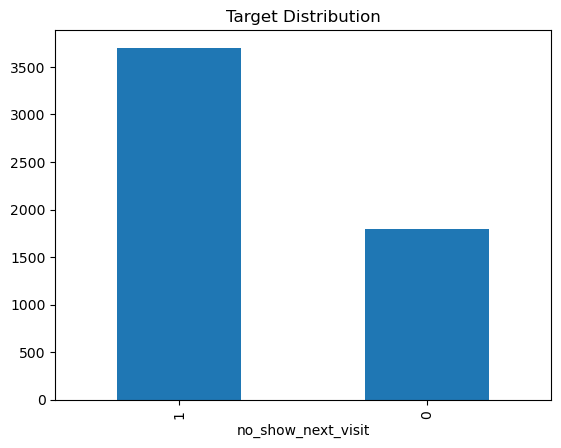

In [9]:
tc = df[target_col].value_counts(dropna=False)
tp = (df[target_col].value_counts(normalize=True)*100).round(2)
print("Counts:\n", tc)
print("\nPercentages:\n", tp)

tc.plot(kind="bar"); plt.title("Target Distribution"); plt.show()


### Your Answer
Our class distribution for our target is 67.31% (1) to 32.69% (0) showing that there is definitely a mild imbalance in the dataset. Accuracy may not be the best metric to use here because our model could report an accuracy of 67.31% (which is fairly high) just by guessing the majority class every single time. The two metrics I would recommend are as follows:

 1. Recall (Sensitivity for no-shows): Measures the proportion of actual no-shows correctly flagged. In a clinical context, missing a no-show means a wasted appointment slot, lost revenue, and no follow-up care for the patient.
 2. F1 Score: The harmonic mean of precision and recall, balancing both. It penalizes models that are either too aggressive (flagging everyone as no-show) or too passive.

Maximizing recall will flag more patients as likely no-shows, enabling proactive outreach, but at the cost of precision, meaning many patients who would have attended get unnecessary calls. This wastes outreach resources and may annoy reliable patients. Maximizing F1 balances this but may not catch enough true no-shows. I would say to Prioritize Recall, with F1 as a secondary check. We do not need to have only one metric, we can learn from both. In a healthcare no-show context, the cost of a missed no-show (empty slot, missed care) is higher than the cost of an unnecessary reminder call.

## Q5. Repeated Entities & Leakage (8 pts)

**Task**
- Show evidence of repeated patients (numbers).
- Explain **why independence is violated**.
- **Predict**: will random split be higher/lower than grouped? Why?
- Recommend a **validation strategy**.

**Requirement**
- Include a **prediction before modeling** and a decision.


In [10]:
n_rows = len(df)
if "patient_id" in df.columns:
    n_pat = df["patient_id"].nunique()
    print("Rows:", n_rows)
    print("Unique patients:", n_pat)
    print("Avg records per patient:", round(n_rows/n_pat, 2))
    vc = df["patient_id"].value_counts()
    print("Patients with >1 record:", (vc>1).sum())
    print("Max records for one patient:", vc.max())


Rows: 5500
Unique patients: 1719
Avg records per patient: 3.2
Patients with >1 record: 1442
Max records for one patient: 10


### Your Answer
Each one of our rows from our dataset is for an appointment **NOT** for a patient, meaning that the target which we are trying to predict on (patient dependent) has multiple records for that patient. So we do not truly have an independent relationship between our predictors and target. We will have highly correlated data across a given patient's records. A random train/test split will definitely put some of one patient's appointments in training and others in test, the model then can recognize the patient leading to data leakage.

The random split will yield higher F1/recall/accuracy than the grouped split. Because the random split leaks patient data into the test set, the model gets an unfair advantage because it has already "seen" versions of the same patients during training.

As mentioned earlier the best way to mitigate that is to use GroupShuffleSplit(groups=patient_id) for all evaluation. This ensures that the model is validated specifically on patients never seen in training.

## Q6. Suspicious Feature Identification (7 pts)

**Task**
- Identify **three suspicious features**.
- For each: why suspicious, possible issue, how to test.
- Select the **most dangerous** and justify.

**Requirement**
- Use **data meaning/timing** reasoning, not generic statements.


### Your Answer

The first suspicious feature is historical_no_show_rate. As confirmed in Q3, this is a static per-patient value computed exactly as prior_no_show_count / prior_total_appointments, never updating across a patient's appointments. While the grouped split resolves the cross-contamination risk, the feature still represents a fixed historical snapshot rather than a true rolling calculation, meaning it overstates what you would genuinely know at the time of each appointment. It is retained but flagged as imperfect.

The second suspicious feature is visit_gap_estimate. The name including "estimate" signals that this is a derived or model-generated field rather than a raw observation, and its wide range (1 to 74.63) is consistent with an engineered score. If this was computed using future appointment outcomes or the target variable as an input, it would be direct leakage. Unlike historical_no_show_rate, there is no transparent formula we can verify from the data alone, making it more dangerous.

The third feature that looks a bit suspicious is attendance_stability_index. It’s a composite score from 5 to 100 that’s supposed to represent how consistent a patient’s past attendance is, but it’s not really clear how it’s actually calculated. Similar to visit_gap_estimate, the formula isn’t transparent. Since it’s basically summarizing attendance behavior, which is exactly what we’re trying to predict, there’s a risk that it’s leaking information, especially if it was computed using data that includes the visit we’re trying to predict.

## Q7. Confounding Analysis (7 pts)

**Task**
- Identify **one misleading feature–target relationship**.
- Describe the observed pattern.
- Explain **why it is misleading** (confounding).
- Decide: **keep or remove**, and why.

**Requirement**
- Provide a **real-world explanation**.


In [11]:
# Q7: Investigating SMS count vs no-show rate (confounding check)
print("Average SMS sent by no-show outcome:")
print(df.groupby("no_show_next_visit")["sms_sent_count_30d"].mean().round(3))

print("\nAverage SMS sent by historical_no_show_rate quartile:")
df["nsrate_quartile"] = pd.qcut(df["historical_no_show_rate"], q=4, labels=["Q1","Q2","Q3","Q4"])
print(df.groupby("nsrate_quartile", observed = False)["sms_sent_count_30d"].mean().round(3))

print("\nNo-show rate by SMS count bucket:")
df["sms_bucket"] = pd.cut(df["sms_sent_count_30d"], bins=[-1,1,3,5,8], labels=["0-1","2-3","4-5","6-8"])
print(df.groupby("sms_bucket", observed = False)["no_show_next_visit"].mean().round(3))

df.drop(columns=["nsrate_quartile", "sms_bucket"], inplace=True)

Average SMS sent by no-show outcome:
no_show_next_visit
0    3.828
1    4.229
Name: sms_sent_count_30d, dtype: float64

Average SMS sent by historical_no_show_rate quartile:
nsrate_quartile
Q1    3.198
Q2    4.324
Q3    4.446
Q4    4.423
Name: sms_sent_count_30d, dtype: float64

No-show rate by SMS count bucket:
sms_bucket
0-1    0.578
2-3    0.647
4-5    0.694
6-8    0.717
Name: no_show_next_visit, dtype: float64


### Your Answer

The misleading relationship that I identified is between sms_sent_count_30d and no_show_next_visit. It initially seems like patients who received more SMS reminders in the last 30 days appear to have higher no-show rates, which seems counterintuitive because more reminders should reduce no-shows. However, this relationship is confounded by prior no-show history. Patients with a long history of missing appointments are precisely the ones the clinic targets with aggressive outreach, meaning high SMS counts are a response to known high-risk behavior rather than a cause of no-shows. The true driver is the patient's underlying attendance behavior. The SMS count is just showing how worried the clinic already was about that patient. This makes the raw correlation between SMS volume and no-shows misleading if interpreted causally. The decision is to keep the feature becuase it still carries legitimate predictive signal about patient risk, but it should not be interpreted as evidence that SMS reminders increase no-shows.

## Q8. Validation Comparison (9 pts)

**Task**
- Run **random split** and **grouped split**.
- Report metrics.
- Explain **why they differ**.
- Decide which is **more trustworthy**.
- Compare with your **prediction in Q5**.

**Requirement**
- Must reference **actual scores** and connect to Q5.


In [12]:
X = df.drop(columns=[target_col])
y = df[target_col]

cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

model = Pipeline([("prep", prep), ("m", LogisticRegression(max_iter=1000))])

# Random split
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model.fit(Xr_tr, yr_tr)
pr = model.predict(Xr_te)

print("Random -> F1:", round(f1_score(yr_te, pr),4),
      "Prec:", round(precision_score(yr_te, pr),4),
      "Rec:", round(recall_score(yr_te, pr),4),
      "Acc:", round(accuracy_score(yr_te, pr),4))

# Grouped split
groups = df["patient_id"] if "patient_id" in df.columns else np.arange(len(df))
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(gss.split(X, y, groups=groups))
Xg_tr, Xg_te = X.iloc[tr_idx], X.iloc[te_idx]
yg_tr, yg_te = y.iloc[tr_idx], y.iloc[te_idx]

model.fit(Xg_tr, yg_tr)
pg = model.predict(Xg_te)

print("Grouped -> F1:", round(f1_score(yg_te, pg),4),
      "Prec:", round(precision_score(yg_te, pg),4),
      "Rec:", round(recall_score(yg_te, pg),4),
      "Acc:", round(accuracy_score(yg_te, pg),4))


Random -> F1: 0.799 Prec: 0.757 Rec: 0.8459 Acc: 0.7136
Grouped -> F1: 0.7777 Prec: 0.7179 Rec: 0.8484 Acc: 0.6856


### Your Answer
Running both splits on a logistic regression baseline produced the following results: the random split achieved F1 of 0.799, precision of 0.757, recall of 0.8459, and accuracy of 0.7136, while the grouped split achieved F1 of 0.7777, precision of 0.7179, recall of 0.8484, and accuracy of 0.6856. The random split outperforms the grouped split on F1 and accuracy by approximately 2.1 and 2.8 percentage points respectively. This gap exists because the random split places different appointments from the same patient in both train and test, allowing the model to essentialy recognize patients it has already seen through their fixed behavioral features like historical_no_show_rate and prior_no_show_count. The grouped split forces the evaluation on entirely unseen patients, which is the correct way to train the model. The grouped split is therefore the more trustworthy evaluation. This confirms the prediction made in Q5, random split performance is inflated relative to grouped, and the gap is because of patient-level memorization rather than generalization skill.

## Q9. Model Improvement & Trust (9 pts)

**Task**
- Build an **improved model** (e.g., remove suspicious features, change algorithm).
- Compare with baseline (use grouped split).
- Explain **why performance changed**.
- Decide whether the improvement is **real or misleading**.


In [13]:
# Edit drop list as needed
drop_cols = ["appointment_id", "patient_id", "scheduled_date", "appointment_date",
             "visit_gap_estimate", "return_propensity_index", "care_continuity_score",
             "contact_efficiency_score", "utilization_pattern_score", 
             "schedule_pressure_score", "attendance_stability_index"]  # e.g., ["patient_id", "visit_gap_estimate"]

X_imp = df.drop(columns=[target_col] + drop_cols)
y_imp = df[target_col]

cat_cols = X_imp.select_dtypes(include=["object","category"]).columns.tolist()
num_cols = [c for c in X_imp.columns if c not in cat_cols]

prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

rf = Pipeline([("prep", prep), ("m", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))])

groups = df["patient_id"] if "patient_id" in df.columns else np.arange(len(df))
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(gss.split(X_imp, y_imp, groups=groups))
X_tr, X_te = X_imp.iloc[tr_idx], X_imp.iloc[te_idx]
y_tr, y_te = y_imp.iloc[tr_idx], y_imp.iloc[te_idx]

rf.fit(X_tr, y_tr)
p_imp = rf.predict(X_te)

print("Improved -> F1:", round(f1_score(y_te, p_imp),4),
      "Prec:", round(precision_score(y_te, p_imp),4),
      "Rec:", round(recall_score(y_te, p_imp),4),
      "Acc:", round(accuracy_score(y_te, p_imp),4))
print("Confusion matrix:\n", confusion_matrix(y_te, p_imp))


Improved -> F1: 0.8014 Prec: 0.7111 Rec: 0.918 Acc: 0.705
Confusion matrix:
 [[124 273]
 [ 60 672]]


### Your Answer

The improved model is a Random Forest with 300 estimators, evaluated using the same grouped split as the baseline. The composite scores with no given computation formula were removed, specifically visit_gap_estimate, return_propensity_index, care_continuity_score, contact_efficiency_score, utilization_pattern_score, schedule_pressure_score, and attendance_stability_index. I also removed non-predictive identifiers: appointment_id, patient_id, scheduled_date, and appointment_date. The improved model achieved F1 of 0.8014, precision of 0.7111, recall of 0.918, and accuracy of 0.705, compared to the grouped logistic regression baseline of F1 0.7777, precision 0.7179, recall 0.8484, and accuracy 0.6856. The confusion matrix showed 672 true positives, 124 true negatives, 60 false negatives, and 273 false positives. The Random Forest improved F1 by 2.4 percentage points and recall substantially from 0.8484 to 0.918, meaning it now catches 91.8% of actual no-shows, however, we do have a minor precision drop from 0.7179 to 0.7111. The performance change is definitely real and not misleading because both models were evaluated under identical grouped split conditions. The improvement comes from the Random Forest's ability to capture non-linear interactions (as well as reducing our feature set) between features that logistic regression treats as independent, not from any change in how we are evaluating.

## Q10. Final Recommendation (9 pts)

**Task**
- Should the model be **deployed now**? Why/why not?
- List **key risks/limitations**.
- What additional information is needed?
- What could go wrong if deployed too early?

**Requirement**
- Connect to your findings from earlier questions.


### Your Answer

The model should not be deployed yet. While the improved Random Forest achieves a recall of 0.918 and F1 of 0.8014 on the grouped split, which is a meaningful improvement over the logistic regression baseline. There are still several risks that are left over which would make deployment dangerous as of right now. The biggest concern identified in Q6 is the presence of composite features that we dont know anything about their computation formulas, and while several suspicious ones were removed in Q9, the remaining features include historical_no_show_rate which as confirmed in Q3 is static rather than a true rolling calculation, meaning it slightly misrepresents what would genuinely be known at prediction time for each individual appointment.

Another issue is that the model has only been validated using a patient-level split, not a time-based one. While the grouped split makes sure we’re testing on new patients, it doesn’t tell us how the model performs over time as things like clinic operations, patient populations, or reminder strategies change. For example, a model trained on 2025 data might not generalize well to future periods if scheduling patterns or provider workloads shift. Also, like we saw in Q7, there’s confounding between SMS volume and no-show history, so the model might be picking up on clinic behavior just as much as patient behavior. If the outreach strategy changes, those patterns might break down. Finally, with a precision of 0.7111, about 1 in 3 flagged patients won’t actually no-show, which at scale could waste resources and potentially frustrate patients who are consistently reliable but keep getting flagged.

Before deploying, we need to make sure we fully understand how all the remaining derived features are calculated, especially the time windows they use, and confirm that every feature is actually available before the appointment happens. We should also run a proper time-based validation where we train on earlier months and test on later ones. If we skip this and deploy too early, the biggest risk is that our grouped-split results are overly optimistic, the model ends up triggering interventions based on patterns that don’t hold in the future, and by the time we notice performance dropping, it’s already been impacting outreach decisions at scale.